# Day 48 - Gradient Problems & Activation Functions

- Vanishing and exploding gradients
- Signal flow
- Glorot/Xavier initialization
- He initialization
- ReLU and dying ReLU
- Leaky ReLU
- ELU
- SELU
- Activation + initialization choices
- Practical TensorFlow/Keras experiments


In [13]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

np.random.seed(42)
tf.random.set_seed(42)


TensorFlow: 2.21.0
Keras: 3.15.1


## 1. Vanishing vs exploding gradients

During backpropagation, gradients are repeatedly transformed as they travel through many layers.

- **Vanishing gradients:** values become extremely small, so early layers learn very slowly.
- **Exploding gradients:** values become extremely large, causing unstable updates and potentially `NaN` loss.

A simple intuition:

> Repeated multiplication by numbers below 1 tends toward zero; repeated multiplication by numbers above 1 can grow rapidly.


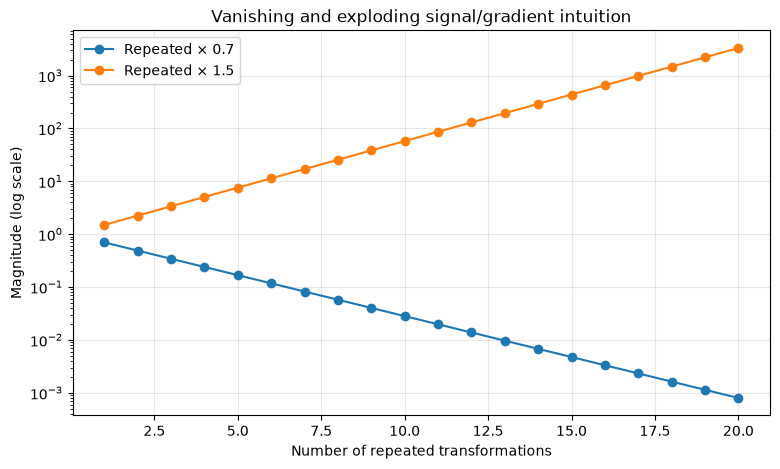

In [14]:
# Simple illustration of repeated multiplication

steps = np.arange(1, 21)
vanishing = 0.7 ** steps
exploding = 1.5 ** steps

plt.figure(figsize=(9, 5))
plt.plot(steps, vanishing, marker="o", label="Repeated × 0.7")
plt.plot(steps, exploding, marker="o", label="Repeated × 1.5")
plt.yscale("log")
plt.xlabel("Number of repeated transformations")
plt.ylabel("Magnitude (log scale)")
plt.title("Vanishing and exploding signal/gradient intuition")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 2. Why sigmoid can contribute to vanishing gradients

The sigmoid function saturates toward 0 and 1. In those saturated regions, its derivative becomes very small.

In a deep network, repeatedly multiplying by small derivatives can make gradients nearly disappear.

This is one reason modern deep networks generally prefer nonsaturating hidden-layer activations such as ReLU and its variants.


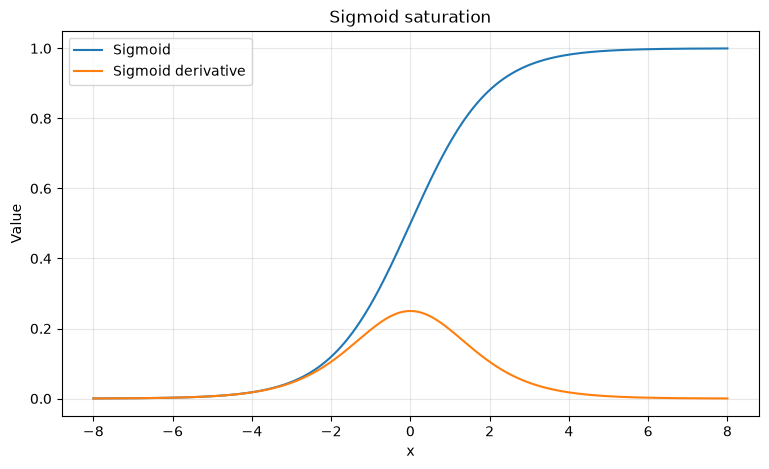

In [15]:
# Sigmoid and its derivative

x = np.linspace(-8, 8, 500)
sigmoid = 1 / (1 + np.exp(-x))
sigmoid_derivative = sigmoid * (1 - sigmoid)

plt.figure(figsize=(9, 5))
plt.plot(x, sigmoid, label="Sigmoid")
plt.plot(x, sigmoid_derivative, label="Sigmoid derivative")
plt.xlabel("x")
plt.ylabel("Value")
plt.title("Sigmoid saturation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 3. Initialization

Initialization controls the starting scale of weights.

Poor initialization can make activations and gradients shrink or grow systematically across layers.

### Glorot / Xavier
Commonly associated with **sigmoid and tanh**.

### He
Designed for **ReLU-family** activations.

### LeCun
Commonly paired with **SELU**.

### Memory shortcut

`Sigmoid/Tanh → Glorot`  
`ReLU family → He`  
`SELU → LeCun`


## 4. Activation functions

### ReLU
`max(0, z)`

Fast and simple. Its positive side does not saturate, but neurons can become permanently inactive when they stay in the negative region.

### Leaky ReLU
Keeps a small negative slope, reducing the risk of a completely zero gradient on the negative side.

### ELU
Acts like ReLU for positive inputs and smoothly approaches a negative value for negative inputs.

### SELU
A scaled ELU designed to encourage self-normalizing behavior when the required conditions are satisfied.


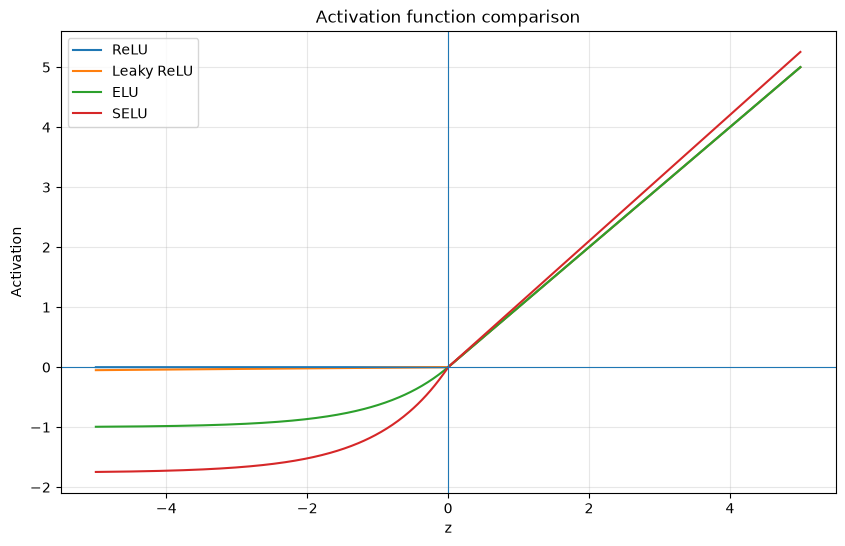

In [16]:
# Compare ReLU, Leaky ReLU, ELU and SELU

x = np.linspace(-5, 5, 500)

relu = np.maximum(0, x)
leaky_relu = np.where(x >= 0, x, 0.01 * x)

alpha = 1.0
elu = np.where(x >= 0, x, alpha * (np.exp(x) - 1))

selu_lambda = 1.0507009873554805
selu_alpha = 1.6732632423543772
selu = selu_lambda * np.where(
    x >= 0,
    x,
    selu_alpha * (np.exp(x) - 1)
)

plt.figure(figsize=(10, 6))
plt.plot(x, relu, label="ReLU")
plt.plot(x, leaky_relu, label="Leaky ReLU")
plt.plot(x, elu, label="ELU")
plt.plot(x, selu, label="SELU")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.xlabel("z")
plt.ylabel("Activation")
plt.title("Activation function comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 5. Dying ReLU

For ordinary ReLU:

- `z > 0` → gradient is 1
- `z < 0` → gradient is 0

A neuron that consistently receives negative pre-activation values can therefore stop learning.

Leaky ReLU avoids a completely flat negative side by retaining a small slope.


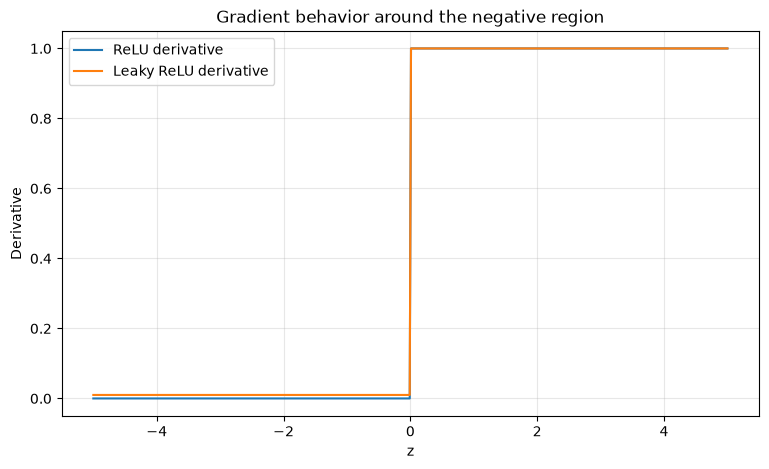

In [17]:
# ReLU vs Leaky ReLU derivative

relu_derivative = np.where(x > 0, 1.0, 0.0)
leaky_derivative = np.where(x > 0, 1.0, 0.01)

plt.figure(figsize=(9, 5))
plt.plot(x, relu_derivative, label="ReLU derivative")
plt.plot(x, leaky_derivative, label="Leaky ReLU derivative")
plt.xlabel("z")
plt.ylabel("Derivative")
plt.title("Gradient behavior around the negative region")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Activation + initialization cheat sheet

| Activation | Typical initialization |
|---|---|
| Sigmoid | Glorot/Xavier |
| Tanh | Glorot/Xavier |
| ReLU | He |
| Leaky ReLU | He |
| ELU | He |
| SELU | LeCun |

The pairing is important because initialization is intended to keep signal variance in a useful range for the chosen activation.


## 7. Hands-on Keras experiment

We will compare four common combinations:

1. ReLU + He
2. Leaky ReLU + He
3. ELU + He
4. SELU + LeCun

The experiment is for understanding behavior, not for declaring a universally best activation.


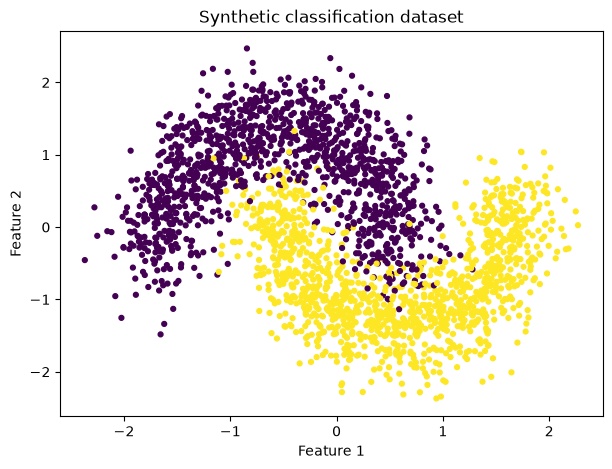

In [18]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(
    n_samples=3000,
    noise=0.20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=12)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic classification dataset")
plt.show()


In [19]:
def build_model(activation_name):
    if activation_name == "relu":
        initializer = "he_normal"
        activation_layers = [
            keras.layers.ReLU(),
            keras.layers.ReLU(),
            keras.layers.ReLU()
        ]
    elif activation_name == "leaky_relu":
        initializer = "he_normal"
        activation_layers = [
            keras.layers.LeakyReLU(negative_slope=0.01),
            keras.layers.LeakyReLU(negative_slope=0.01),
            keras.layers.LeakyReLU(negative_slope=0.01)
        ]
    elif activation_name == "elu":
        initializer = "he_normal"
        activation_layers = [
            keras.layers.ELU(),
            keras.layers.ELU(),
            keras.layers.ELU()
        ]
    elif activation_name == "selu":
        initializer = "lecun_normal"
        activation_layers = [
            keras.layers.Activation("selu"),
            keras.layers.Activation("selu"),
            keras.layers.Activation("selu")
        ]
    else:
        raise ValueError("Unknown activation")

    model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(64, kernel_initializer=initializer),
        activation_layers[0],
        keras.layers.Dense(64, kernel_initializer=initializer),
        activation_layers[1],
        keras.layers.Dense(32, kernel_initializer=initializer),
        activation_layers[2],
        keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [20]:
# Train the four models

activation_names = ["relu", "leaky_relu", "elu", "selu"]
models = {}
histories = {}

for name in activation_names:
    print("Training:", name)
    tf.random.set_seed(42)

    model = build_model(name)
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    models[name] = model
    histories[name] = history

    print(
        "Final validation accuracy:",
        round(history.history["val_accuracy"][-1], 4)
    )


Training: relu
Final validation accuracy: 0.9708
Training: leaky_relu
Final validation accuracy: 0.975
Training: elu
Final validation accuracy: 0.9729
Training: selu
Final validation accuracy: 0.9688


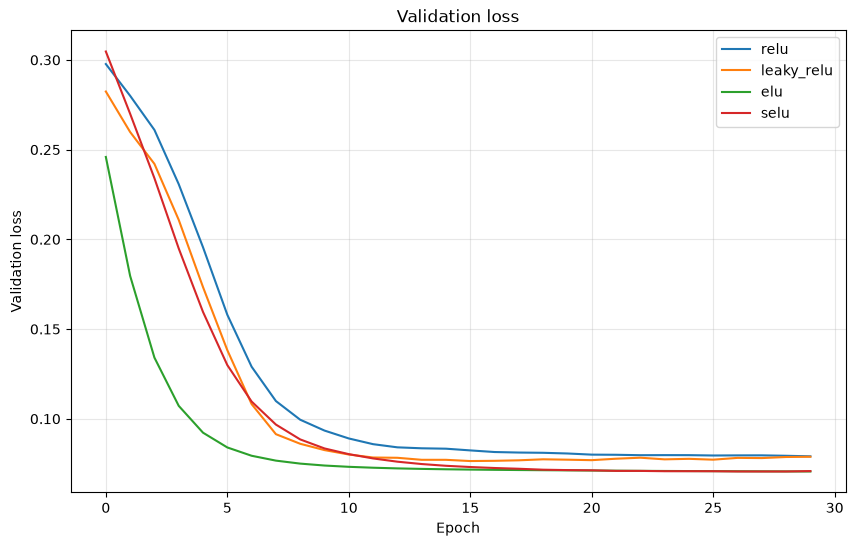

In [21]:
# Validation loss comparison

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


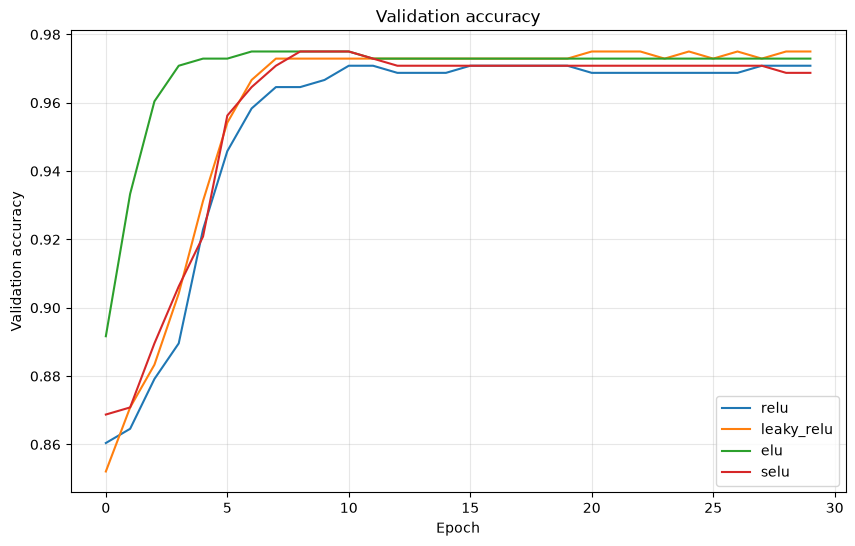

In [22]:
# Validation accuracy comparison

plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Inspect gradient magnitudes

A practical diagnostic is to inspect the average absolute gradient of each trainable variable.

Very small values in early layers may indicate weak gradient flow; extremely large values may indicate unstable gradients.

This is a diagnostic snapshot, not a universal threshold.


In [23]:
def gradient_report(model, x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(y_batch, predictions)
        )

    gradients = tape.gradient(loss, model.trainable_variables)

    report = []
    for variable, gradient in zip(model.trainable_variables, gradients):
        if gradient is not None:
            magnitude = float(tf.reduce_mean(tf.abs(gradient)))
            report.append((variable.name, magnitude))

    return float(loss.numpy()), report


x_batch = tf.convert_to_tensor(X_train[:128], dtype=tf.float32)
# Ensure `y_batch` has shape (batch, 1) to match model output shape (128, 1)
# reshape if y_train is (batch,) -> (batch, 1)
y_batch = tf.convert_to_tensor(y_train[:128].reshape(-1, 1), dtype=tf.float32)

for name in activation_names:
    loss_value, report = gradient_report(
        models[name],
        x_batch,
        y_batch
    )

    print(f"\n{name.upper()} — loss = {loss_value:.6f}")
    for variable_name, magnitude in report:
        print(f"{variable_name:40s} {magnitude:.3e}")



RELU — loss = 0.067612
kernel                                   3.221e-03
bias                                     4.999e-03
kernel                                   9.987e-04
bias                                     2.285e-03
kernel                                   7.072e-04
bias                                     1.898e-03
kernel                                   3.476e-03
bias                                     9.218e-03

LEAKY_RELU — loss = 0.070173
kernel                                   3.105e-03
bias                                     5.109e-03
kernel                                   8.888e-04
bias                                     2.284e-03
kernel                                   8.122e-04
bias                                     2.130e-03
kernel                                   6.762e-03
bias                                     1.009e-02

ELU — loss = 0.074563
kernel                                   1.904e-03
bias                                     4.383e-03
kerne

## 9. Deep network experiment

Gradient issues become more important as depth increases.

The following model has 15 hidden layers and uses the common **ReLU + He** combination.


In [24]:
def build_deep_relu_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(2,))
    ])

    for _ in range(15):
        model.add(
            keras.layers.Dense(
                64,
                activation="relu",
                kernel_initializer="he_normal"
            )
        )

    model.add(keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


deep_model = build_deep_relu_model()

deep_history = deep_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=0
)

print("Final validation accuracy:",
      round(deep_history.history["val_accuracy"][-1], 4))


Final validation accuracy: 0.9708


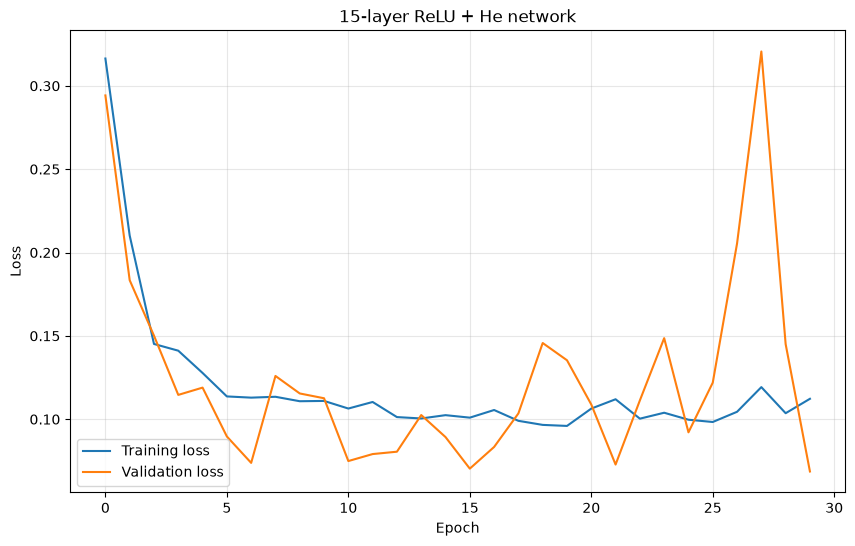

In [25]:
# Plot deep-model training history

plt.figure(figsize=(10, 6))
plt.plot(deep_history.history["loss"], label="Training loss")
plt.plot(deep_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("15-layer ReLU + He network")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Quick revision

## Gradient problems
- **Vanishing:** gradients become too small.
- **Exploding:** gradients become too large.

## Initialization
- **Glorot/Xavier → Sigmoid/Tanh**
- **He → ReLU family**
- **LeCun → SELU**

## Activations
- **ReLU:** fast and simple; possible dying neurons.
- **Leaky ReLU:** small negative slope.
- **ELU:** smooth negative region.
- **SELU:** self-normalizing behavior under suitable conditions.

## Core mental model

**Good initialization keeps signals at a useful scale.**  
**Suitable activation functions help information and gradients flow through deep networks.**
